In [189]:
import numpy as np
import scienceplots
import matplotlib.pyplot as plt
# initialize
#u0 = 1.682*10**-21 #Joules
#r0 = 3.86*10**-10 #meters
#k=1.38*10**-23 #Joules / Kelvin

#u0 = 0.0105 #eV
#r0 = 3.86 #Angstroms
#k = 8.617*10**-5 #Joules / Kelvin
k = 1
u0=4
r0=3


In [56]:
def LJ(r):
        value = u0 * (((r0/r)**12)-(2*((r0/r)**6)))
        return value

In [62]:
def Simpson(T,a,b,num_points):
    def function(r,T):
        value = (r**2) 
        value *=LJ(r)
        value *= np.exp(-LJ(r)/(k*T))
        return value
    dr = (b-a)/num_points
    integral = function(a,T)
    for i in range(1,num_points,2):
        integral += 4*function(a+(i*dr),T)
    for i in range(2,num_points-2,2):
        integral += 2*function(a+(i*dr),T)
    integral += function(b,T)
    integral *= (dr/3)
    return integral

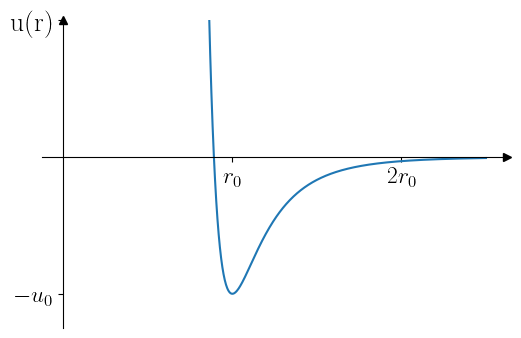

In [134]:
r0=10
r = np.linspace(0.1*r0,2.5*r0,1000)
pot = LJ(r)
#plt.yscale('log')
#plt.style.use('science')
plt.style.use('default')
plt.figure(figsize=(6,4))
plt.plot(r,pot)
plt.ylim(-1.25*u0,1*u0)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 17
})
ax = plt.gca()
ax.spines[['left','bottom']].set_position(('data',0))
ax.spines[['top','right']].set_visible(False)
ax.plot(1,0,">k",transform=ax.get_yaxis_transform(),clip_on=False)
ax.plot(0,1,"^k",transform=ax.get_xaxis_transform(),clip_on=False)

#plt.xlabel("hello")
ax.get_yticklabels()[0].set_fontsize(20)
ax.get_yticklabels()[0].set_fontstyle('italic')
plt.xticks((1*r0,2*r0),[r"$r_0$",r"$2r_0$",])
plt.yticks((1*u0,-u0),[r"u(r)",r"$-u_0$"])


#plt.tick_params(top=False,right=False)

plt.show()

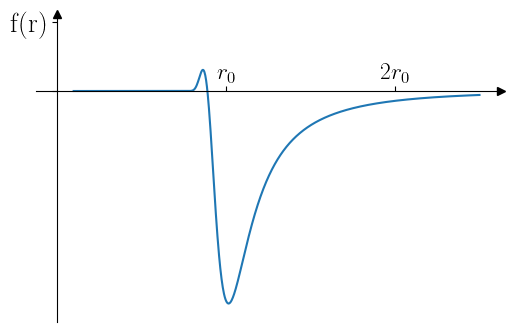

In [153]:
r0=10
r = np.linspace(0.1*r0,2.5*r0,1000)
integrand =(r**2) *LJ(r)*np.exp(-LJ(r))
#plt.yscale('log')
#plt.style.use('science')
plt.style.use('default')
plt.figure(figsize=(6,4))
plt.plot(r,integrand)
plt.ylim(-300*u0,100*u0)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 17
})
ax = plt.gca()
ax.spines[['left','bottom']].set_position(('data',0))
ax.spines[['top','right']].set_visible(False)
ax.plot(1,0,">k",transform=ax.get_yaxis_transform(),clip_on=False)
ax.plot(0,1,"^k",transform=ax.get_xaxis_transform(),clip_on=False)

#plt.xlabel("hello")
ax.get_yticklabels()[0].set_fontsize(20)
ax.get_yticklabels()[0].set_fontstyle('italic')
plt.xticks((1*r0,2*r0),[r"$r_0$",r"$2r_0$",])
plt.yticks((90*u0,0),[r"f(r)",""])
ax.tick_params(axis='x',direction='in',bottom=True,top=False,pad=-20)

#plt.tick_params(top=False,right=False)

plt.show()

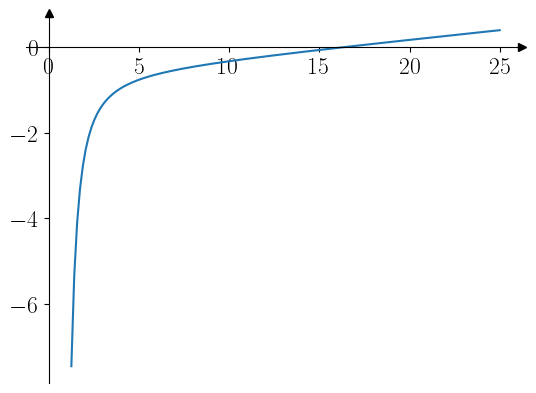

In [199]:
## Calculate Integral
TMax = 100/u0
TMin = 5/u0
num_T = 150
T_list = np.linspace(TMin,TMax,num_T)
dT = (TMax-TMin)/num_T
U_list = []
for T in T_list:
    dU = 2*np.pi*Simpson(T,0.1*r0,1*r0,200)/(u0*(r0**3))
    U_list.append(dU)
plt.plot(T_list,U_list)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 17
})
ax = plt.gca()
ax.spines[['left','bottom']].set_position(('data',0))
ax.spines[['top','right']].set_visible(False)
ax.plot(1,0,">k",transform=ax.get_yaxis_transform(),clip_on=False)
ax.plot(0,1,"^k",transform=ax.get_xaxis_transform(),clip_on=False)


plt.show()

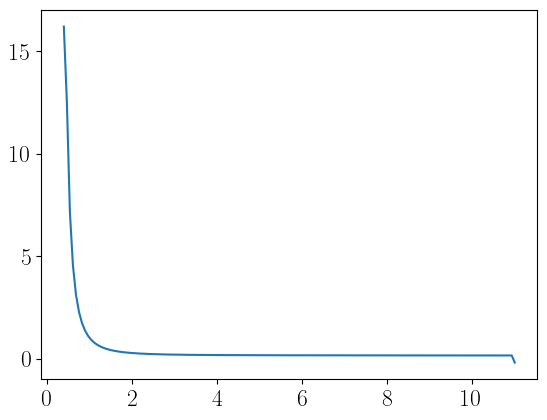

In [119]:
C_list = []
C_list.append((U_list[1]-U_list[0])/dT) #C_0
for i in range(1,len(U_list)-1):
    C_list.append((U_list[i+1]-U_list[i-1])/(2*dT)) # C_i, for 1 < i < end-2
C_list.append((U_list[-2]-U_list[-1])/dT)
plt.plot(T_list,C_list)
plt.show()

In [ ]:
#TODO show total energy, comparing ideal and non-ideal
#TODO: connect to Van der Waals?
#TODO: Do the derivation if the integral
#TODO Derive the integral for the Triangle terms?